# Python Programming — Exercises n. 1

> **Instructor version.**  
> Each exercise is followed by one possible solution. The solutions are intentionally written in a clear and explicit style rather than compressed into the shortest possible code.

In [1]:
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Exercise 1 — A simple risk-scoring model

A simple model assigns a risk score to a patient using

$$
s = 0.04(\text{age}-50)
+ 0.8(\text{biomarker}-4)
+ 0.6\,\text{smoker}.
$$

Here `smoker` is `1` for a smoker and `0` otherwise.

The predicted class is

$$
\hat y =
\begin{cases}
1 & s > 0,\\
0 & \text{otherwise}.
\end{cases}
$$

Use the following data:

In [2]:
patients = [
    {"age": 37, "biomarker": 3.8, "smoker": 0},
    {"age": 63, "biomarker": 5.1, "smoker": 1},
    {"age": 52, "biomarker": 4.7, "smoker": 0},
    {"age": 71, "biomarker": 3.9, "smoker": 1},
    {"age": 45, "biomarker": 5.4, "smoker": 0},
    {"age": 58, "biomarker": 4.6, "smoker": 1},
    {"age": 34, "biomarker": 4.1, "smoker": 0},
    {"age": 67, "biomarker": 5.6, "smoker": 1},
    {"age": 49, "biomarker": 3.6, "smoker": 0},
    {"age": 55, "biomarker": 4.3, "smoker": 1},
    {"age": 73, "biomarker": 5.0, "smoker": 0},
    {"age": 41, "biomarker": 4.9, "smoker": 1},
    {"age": 60, "biomarker": 3.7, "smoker": 0},
    {"age": 46, "biomarker": 5.2, "smoker": 1},
    {"age": 69, "biomarker": 4.4, "smoker": 1},
    {"age": 38, "biomarker": 3.5, "smoker": 0},
    {"age": 57, "biomarker": 5.5, "smoker": 0},
    {"age": 64, "biomarker": 4.0, "smoker": 1},
    {"age": 50, "biomarker": 4.8, "smoker": 0},
    {"age": 43, "biomarker": 4.2, "smoker": 1},
    {"age": 76, "biomarker": 5.3, "smoker": 1},
    {"age": 32, "biomarker": 4.6, "smoker": 0},
    {"age": 61, "biomarker": 5.0, "smoker": 0},
    {"age": 54, "biomarker": 3.9, "smoker": 1},
]


### Tasks

1. Compute the score for every patient.
2. Create a **new list of dictionaries** containing the original data plus:
   - `"score"`
   - `"prediction"`
3. Count how many patients are classified as positive.
4. Find the patient with the highest score.
5. Print one line per patient, for example:

```text
Patient 3: score = 0.84 -> positive
```

### Think before coding

Which quantities are the **features**, which part is the **model**, and which quantity is the **prediction**?

## Solution

In [3]:
results = []

for patient in patients:
    score = (
        0.04 * (patient["age"] - 50)
        + 0.8 * (patient["biomarker"] - 4)
        + 0.6 * patient["smoker"]
    )
    prediction = int(score > 0)

    result = patient.copy()
    result["score"] = score
    result["prediction"] = prediction
    results.append(result)


In [4]:
for i, patient in enumerate(results, start=1):
    label = "positive" if patient["prediction"] == 1 else "negative"
    print(f"Patient {i}: score = {patient['score']:.2f} -> {label}")



Patient 1: score = -0.68 -> negative
Patient 2: score = 2.00 -> positive
Patient 3: score = 0.64 -> positive
Patient 4: score = 1.36 -> positive
Patient 5: score = 0.92 -> positive
Patient 6: score = 1.40 -> positive
Patient 7: score = -0.56 -> negative
Patient 8: score = 2.56 -> positive
Patient 9: score = -0.36 -> negative
Patient 10: score = 1.04 -> positive
Patient 11: score = 1.72 -> positive
Patient 12: score = 0.96 -> positive
Patient 13: score = 0.16 -> positive
Patient 14: score = 1.40 -> positive
Patient 15: score = 1.68 -> positive
Patient 16: score = -0.88 -> negative
Patient 17: score = 1.48 -> positive
Patient 18: score = 1.16 -> positive
Patient 19: score = 0.64 -> positive
Patient 20: score = 0.48 -> positive
Patient 21: score = 2.68 -> positive
Patient 22: score = -0.24 -> negative
Patient 23: score = 1.24 -> positive
Patient 24: score = 0.68 -> positive


In [5]:
n_positive = sum(patient["prediction"] for patient in results)
highest_risk = max(results, key=lambda p: p["score"])

print("Number of positive predictions:", n_positive)
print("Highest score:", highest_risk)

Number of positive predictions: 19
Highest score: {'age': 76, 'biomarker': 5.3, 'smoker': 1, 'score': 2.68, 'prediction': 1}


### Part 2 — Analyze the results with pandas

Convert the list of dictionaries containing the computed scores and predictions into a pandas `DataFrame`.

Then compare score statistics for smokers and non-smokers and visualize the two distributions.

The same grouped comparison can also be visualized using pandas plotting utilities, for example through plotting methods applied after `df_patients.groupby(...)`.

,age,biomarker,smoker,score,prediction
0,37,3.8,0,-0.68,0
1,63,5.1,1,2.00,1
2,52,4.7,0,0.64,1
3,71,3.9,1,1.36,1
4,45,5.4,0,0.92,1
5,58,4.6,1,1.40,1
6,34,4.1,0,-0.56,0
7,67,5.6,1,2.56,1
8,49,3.6,0,-0.36,0
9,55,4.3,1,1.04,1


Score summary by smoking status:


,count,mean,median,std
smoker,,,,
0,12,0.34,0.40,0.890761
1,12,1.45,1.38,0.683547


Mean score — non-smokers: 0.340
Mean score — smokers:     1.450

In this synthetic dataset, smokers have a higher average predicted risk score.


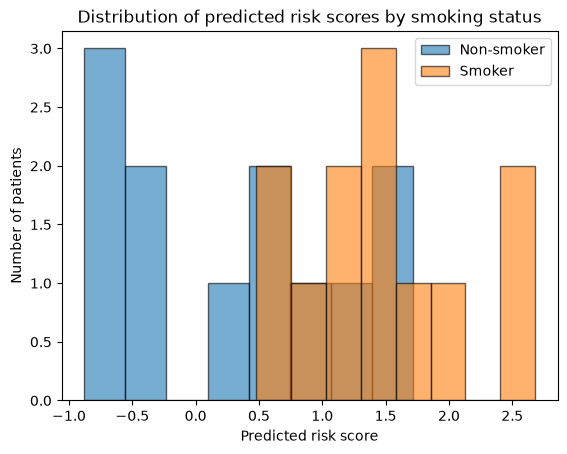

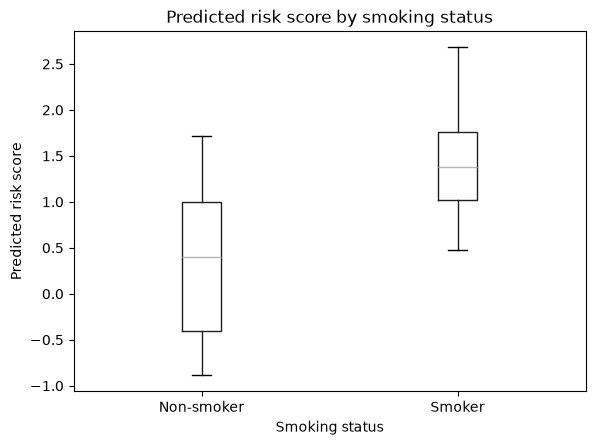

In [6]:
df_patients = pd.DataFrame(results)

display(df_patients)

# ---------------------------------------------------------
# Grouped summary statistics
# ---------------------------------------------------------

score_summary = (
    df_patients
    .groupby("smoker")["score"]
    .agg(["count", "mean", "median", "std"])
)

print("Score summary by smoking status:")
display(score_summary)

mean_non_smoker = score_summary.loc[0, "mean"]
mean_smoker = score_summary.loc[1, "mean"]

print(f"Mean score — non-smokers: {mean_non_smoker:.3f}")
print(f"Mean score — smokers:     {mean_smoker:.3f}")

if mean_smoker > mean_non_smoker:
    print("\nIn this synthetic dataset, smokers have a higher average predicted risk score.")
else:
    print("\nIn this synthetic dataset, smokers do not have a higher average predicted risk score.")


# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

non_smoker_scores = df_patients.loc[
    df_patients["smoker"] == 0, "score"
]

smoker_scores = df_patients.loc[
    df_patients["smoker"] == 1, "score"
]

plt.hist(
    non_smoker_scores,
    bins=8,
    alpha=0.6,
    label="Non-smoker",
    edgecolor="black"
)

plt.hist(
    smoker_scores,
    bins=8,
    alpha=0.6,
    label="Smoker",
    edgecolor="black"
)

plt.xlabel("Predicted risk score")
plt.ylabel("Number of patients")
plt.title("Distribution of predicted risk scores by smoking status")
plt.legend()
plt.show()


# ---------------------------------------------------------
# Boxplot
# ---------------------------------------------------------

df_plot = df_patients.copy()
df_plot["smoking_status"] = df_plot["smoker"].map({
    0: "Non-smoker",
    1: "Smoker"
})

df_plot.boxplot(
    column="score",
    by="smoking_status",
    grid=False
)

plt.xlabel("Smoking status")
plt.ylabel("Predicted risk score")
plt.title("Predicted risk score by smoking status")
plt.suptitle("")
plt.show()


The patient variables are the **features**.  
The formula defining `score` is the **model**.  
The thresholding rule converts the model output into a **prediction**.

# Exercise 2 — Compute classification metrics

A binary classifier produces the following true labels and predictions:

In [7]:
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1]
y_pred = [1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1]

### Tasks

Without using scikit-learn:

1. Count:
   - true positives (`TP`);
   - true negatives (`TN`);
   - false positives (`FP`);
   - false negatives (`FN`).
2. Store the result in a dictionary.
3. Compute accuracy, precision and recall.
4. Implement:

```python
def classification_metrics(y_true, y_pred):
    ...
```

The function should:

- return a dictionary containing the confusion-matrix counts and metrics;
- raise a `ValueError` when the two sequences have different lengths;
- avoid division-by-zero errors.

### Discussion

Why can accuracy be misleading for a highly imbalanced dataset?

## Solution

In [8]:
def classification_metrics(y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length.")

    tp = tn = fp = fn = 0

    for true, pred in zip(y_true, y_pred):
        if true == 1 and pred == 1:
            tp += 1
        elif true == 0 and pred == 0:
            tn += 1
        elif true == 0 and pred == 1:
            fp += 1
        elif true == 1 and pred == 0:
            fn += 1
        else:
            raise ValueError("Labels must be binary: 0 or 1.")

    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0 # high precision means low false allarms
    recall = tp / (tp + fn) if (tp + fn) else 0.0 # how many of the actual positive cases present in the dataset were effectively identified by the model

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }

metrics = classification_metrics(y_true, y_pred)
metrics

{'TP': 5,
 'TN': 4,
 'FP': 1,
 'FN': 2,
 'accuracy': 0.75,
 'precision': 0.8333333333333334,
 'recall': 0.7142857142857143}

Accuracy can look high even when a classifier completely ignores a rare class.  
For example, if only 1% of observations are positive, predicting `0` for every observation gives 99% accuracy but zero recall for the positive class.

# Exercise 3 — Implement k-nearest neighbors

Consider the following two-dimensional synthetic classification dataset.


In [9]:
train_data = [
    # Class 0 — inner region
    ([-0.9,  0.1], 0),
    ([-0.7,  0.6], 0),
    ([-0.6, -0.5], 0),
    ([-0.4,  0.2], 0),
    ([-0.3,  0.8], 0),
    ([-0.2, -0.8], 0),
    ([ 0.0,  0.0], 0),
    ([ 0.1,  0.6], 0),
    ([ 0.2, -0.5], 0),
    ([ 0.4,  0.3], 0),
    ([ 0.5, -0.7], 0),
    ([ 0.6,  0.7], 0),
    ([ 0.7, -0.2], 0),
    ([ 0.8,  0.3], 0),
    ([ 0.0, -1.0], 0),
    ([-1.0, -0.4], 0),

    # Class 1 — outer region
    ([-2.2,  0.0], 1),
    ([-2.0,  0.9], 1),
    ([-1.8, -1.2], 1),
    ([-1.5,  1.6], 1),
    ([-1.3, -1.8], 1),
    ([-0.7,  2.0], 1),
    ([-0.4, -2.1], 1),
    ([ 0.2,  2.2], 1),
    ([ 0.4, -2.0], 1),
    ([ 1.0,  1.8], 1),
    ([ 1.1, -1.7], 1),
    ([ 1.6,  1.3], 1),
    ([ 1.7, -1.0], 1),
    ([ 2.0,  0.6], 1),
    ([ 2.1, -0.3], 1),
    ([ 0.0,  1.7], 1),
    ([-1.6,  0.3], 1),
    ([ 1.4,  0.2], 1),
]

test_points = [
    [0.2, 0.1],
    [1.3, 0.2],
    [-1.1, 1.1],
    [0.3, -1.5],
]

The Euclidean distance between two observations is

$$
d(x,z)=\sqrt{\sum_j (x_j-z_j)^2}.
$$

### Part 1 — Implement kNN

Implement:

```python
def euclidean_distance(x, z):
    ...
```

and then:

```python
def knn_predict(train_data, x_new, k=3):
    ...
```

The classifier should:

1. compute the distance from `x_new` to every training observation;
2. sort observations by distance;
3. select the `k` closest observations;
4. count their labels;
5. return the most frequent class.

Also return the selected neighbors so that the prediction can be inspected.

Classify all observations in `test_points` using `k = 5`.

Then compare the predictions obtained with:

```python
k = 1
k = 3
k = 5
k = 9
```

for at least one test point.

---

### Part 2 — Plot the dataset and predictions

Create a scatter plot of the training data.

- use different colors for the two classes;
- include a legend;
- label the two axes;
- add the test points to the same figure;
- use a visibly different marker for the test points;
- color each test point according to the class predicted by your kNN classifier.

Your plot should make it possible to visually compare the location of a test point with its predicted class.

---

### Part 3 — Visualize the kNN decision regions

A classifier assigns a class not only to the observations in the dataset, but to **every possible point in the feature space**.

To visualize this:

1. create a rectangular grid covering the plotted region using `np.meshgrid`;
2. classify every point in the grid using your `knn_predict` function;
3. reshape the predictions so that they have the same shape as the grid;
4. visualize the predicted classes using `plt.contourf`;
5. plot the original training observations on top of the decision regions.

For example, you may start with:

```python
x1_values = np.linspace(-2.7, 2.7, 120)
x2_values = np.linspace(-2.7, 2.7, 120)

xx, yy = np.meshgrid(x1_values, x2_values)
```

Use `k = 5` for the contour plot.

### Questions

- Is the decision boundary linear?
- Where does the classifier appear most sensitive to individual training points?
- How would you expect the boundary to change when increasing `k`?
- Why is this dataset more suitable than a linearly separable dataset for illustrating kNN?

### Challenge

Raise a meaningful error when `k <= 0` or when `k` is larger than the training set.

## Solution

In [10]:
from math import sqrt

def euclidean_distance(x, z):
    if len(x) != len(z):
        raise ValueError("Points must have the same number of features.")

    squared_sum = 0.0
    for x_j, z_j in zip(x, z):
        squared_sum += (x_j - z_j) ** 2

    return sqrt(squared_sum)


def knn_predict(train_data, x_new, k=3):
    if k <= 0:
        raise ValueError("k must be positive.")
    if k > len(train_data):
        raise ValueError("k cannot be larger than the training set.")

    distances = []

    for features, label in train_data:
        distance = euclidean_distance(features, x_new)
        distances.append((distance, features, label))

    distances.sort(key=lambda item: item[0])
    neighbors = distances[:k]

    counts = {}
    for _, _, label in neighbors:
        counts[label] = counts.get(label, 0) + 1

    prediction = max(counts, key=counts.get)
    return prediction, neighbors


print("Predictions for the test points with k=5:\n")

for point in test_points:
    prediction, neighbors = knn_predict(train_data, point, k=5)
    print(f"{point} -> class {prediction}")


print("\nEffect of k on the point", test_points[1])

for k in [1, 3, 5, 9]:
    prediction, _ = knn_predict(train_data, test_points[1], k=k)
    print(f"k={k}: class {prediction}")

Predictions for the test points with k=5:

[0.2, 0.1] -> class 0
[1.3, 0.2] -> class 0
[-1.1, 1.1] -> class 1
[0.3, -1.5] -> class 0

Effect of k on the point [1.3, 0.2]
k=1: class 1
k=3: class 0
k=5: class 0
k=9: class 0


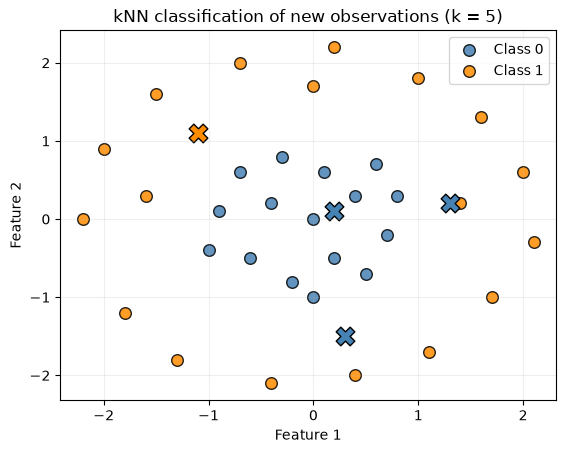

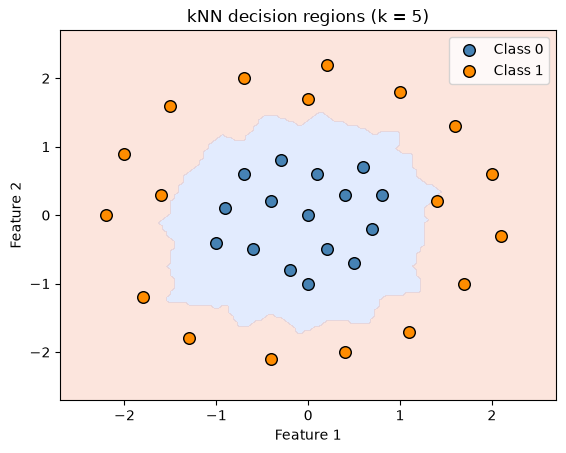

In [25]:
import numpy as np
import matplotlib.pyplot as plt

K = 5
X = np.array([point for point, label in train_data])
y = np.array([label for point, label in train_data])

class_names = {
    0: "Class 0",
    1: "Class 1"
}

class_colors = {
    0: "steelblue",
    1: "darkorange"
}

# Predict the class of each test point.
test_predictions = []

for point in test_points:
    prediction, _ = knn_predict(train_data, point, k=K)
    test_predictions.append(prediction)


# ---------------------------------------------------------
# Plot 1: training observations and classified test points
# ---------------------------------------------------------

for label in np.unique(y):
    mask = (y == label)

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        label=class_names[label],
        color=class_colors[label],
        s=70,
        edgecolor="black",
        alpha=0.85
    )

for point, prediction in zip(test_points, test_predictions):
    plt.scatter(
        point[0],
        point[1],
        color=class_colors[prediction],
        marker="X",
        s=180,
        edgecolor="black"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"kNN classification of new observations (k = {K})")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# ---------------------------------------------------------
# Plot 2: decision regions
# ---------------------------------------------------------

x1_values = np.linspace(-2.7, 2.7, 120)
x2_values = np.linspace(-2.7, 2.7, 120)

xx, yy = np.meshgrid(x1_values, x2_values)

grid_points = np.column_stack([xx.ravel(), yy.ravel()])

grid_predictions = []

for point in grid_points:
    prediction, _ = knn_predict(train_data, point, k=K)
    grid_predictions.append(prediction)

zz = np.array(grid_predictions).reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    zz,
    levels=[-0.5, 0.5, 1.5],
    cmap="coolwarm",
    alpha=0.25
)

for label in np.unique(y):
    mask = y == label

    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        label=class_names[label],
        color=class_colors[label],
        s=70,
        edgecolor="black"
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"kNN decision regions (k = {K})")
plt.legend()
plt.show()

### Discussion

Changing `k` changes how local or smooth the classifier is.  
A very small `k` can produce an irregular decision boundary and can be sensitive to individual observations, while a larger `k` averages information over a wider neighborhood and generally produces smoother regions.

The contour plot makes this effect much easier to see than looking only at predictions for a few individual points.

# Exercise 4 — Train/test split and reproducibility

Machine-learning experiments should separate data used to train a model from data used to evaluate it.

Implement your own train/test split.

In [12]:
data = list(range(100))

### Tasks

Write:

```python
def train_test_split(data, test_fraction=0.2, seed=None):
    ...
```

Requirements:

- the input list must not be modified;
- no element may appear in both subsets;
- every element must appear in exactly one subset;
- the same `seed` must give the same split;
- invalid fractions should raise an error.

Verify your implementation with assertions.

### Discussion

Why is controlling the random seed useful in scientific experiments?

## Solution

In [13]:
def train_test_split(data, test_fraction=0.2, seed=None):
    if not 0 < test_fraction < 1:
        raise ValueError("test_fraction must lie strictly between 0 and 1.")

    rng_local = np.random.default_rng(seed)

    data_copy = list(data)
    indices = rng_local.permutation(len(data_copy))

    n_test = int(round(test_fraction * len(data_copy)))
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    train = [data_copy[i] for i in train_idx]
    test = [data_copy[i] for i in test_idx]

    return train, test


train, test = train_test_split(data, test_fraction=0.2, seed=42)

assert len(train) + len(test) == len(data)
assert set(train).isdisjoint(test)
assert data == list(range(100))

train2, test2 = train_test_split(data, test_fraction=0.2, seed=42)
assert train == train2
assert test == test2

print("Train size:", len(train))
print("Test size:", len(test))
print("First train values:", train[:10])
print("First test values:", test[:10])

Train size: 80
Test size: 20
First train values: [94, 37, 28, 80, 7, 57, 79, 26, 76, 78]
First test values: [59, 21, 56, 18, 33, 42, 50, 27, 92, 71]


A fixed seed makes the random choices reproducible.  
This helps distinguish changes caused by the code or method from changes caused only by a different random split.

# Exercise 5 — Chunked nearest-neighbor search

Full vectorization is not always possible because intermediate arrays may become too large.

Implement nearest-neighbor search by processing the training data in chunks.

In [14]:
rng = np.random.default_rng(123)

X_train = rng.normal(size=(10_000, 10))
X_test = rng.normal(size=(150, 10))

### Tasks

Implement:

```python
def nearest_neighbor_chunked(X_train, X_test, chunk_size=1000):
    ...
```

The function should return, for each test observation:

- the index of its closest training observation;
- the corresponding distance.

Requirements:

- do not construct the complete `(n_test, n_train, n_features)` difference tensor;
- process only one chunk of the training data at a time;
- verify the result against a full vectorized implementation on a smaller subset.

### Discussion

Why can chunking be faster than pure Python while using much less memory than full vectorization?

## Solution

In [15]:
def nearest_neighbor_chunked(X_train, X_test, chunk_size=1000):
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive.")

    best_distances = np.full(len(X_test), np.inf)
    best_indices = np.full(len(X_test), -1, dtype=int)

    for start in range(0, len(X_train), chunk_size):
        stop = min(start + chunk_size, len(X_train))
        chunk = X_train[start:stop]

        differences = X_test[:, None, :] - chunk[None, :, :]
        distances = np.sqrt(np.sum(differences ** 2, axis=2))

        local_indices = np.argmin(distances, axis=1) # index of closest training neigh for each test point
        local_distances = distances[np.arange(len(X_test)), local_indices] # NB: different from distances[:, local_indices] !!

        improved = local_distances < best_distances

        best_distances[improved] = local_distances[improved]
        best_indices[improved] = start + local_indices[improved]

    return best_indices, best_distances


indices_chunked, distances_chunked = nearest_neighbor_chunked(
    X_train, X_test, chunk_size=1000
)

# Validate on a smaller subset with full vectorization.
small_train = X_train[:1000]
small_test = X_test[:20]

full_distances = np.sqrt(
    np.sum(
        (small_test[:, None, :] - small_train[None, :, :]) ** 2,
        axis=2
    )
)

indices_full = np.argmin(full_distances, axis=1)
distances_full = full_distances[np.arange(len(small_test)), indices_full]

indices_check, distances_check = nearest_neighbor_chunked(
    small_train, small_test, chunk_size=200
)

assert np.array_equal(indices_full, indices_check)
assert np.allclose(distances_full, distances_check)

print("First 10 nearest-neighbor indices:")
print(indices_chunked[:10])

print("First 10 distances:")
print(distances_chunked[:10])

First 10 nearest-neighbor indices:
[ 900 3450 9777 8643 6751 6748 4166 4489 4744 8928]
First 10 distances:
[1.80045068 1.29380823 1.55884345 1.82375009 2.02616392 1.46525383
 2.15031987 1.34872264 1.20433437 1.35101361]


Chunking preserves efficient NumPy operations **inside each block**, while limiting the size of temporary arrays.  
It is a useful compromise between Python-level iteration and full vectorization.

# Exercise 6 — Linear regression with linear algebra

Generate noisy observations from approximately

$$
y = 4 + 2.5x.
$$

In [16]:
rng = np.random.default_rng(42)

x = rng.uniform(0, 10, 100)
y = 4 + 2.5 * x + rng.normal(0, 2, size=len(x))

### Tasks

1. Construct the design matrix

$$
X =
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}.
$$

2. Estimate the coefficients with `np.linalg.lstsq`.
3. Print the estimated intercept and slope.
4. Compute predictions and mean squared error.
5. Plot the data and fitted regression line.
6. Compare the estimate with

$$
(X^T X)^{-1}X^Ty.
$$

### Question

Why is explicitly computing a matrix inverse generally less desirable than solving a least-squares problem directly?

## Solution

Estimated intercept: 3.897
Estimated slope:     2.515
MSE:                 3.835
Normal-equation coefficients:
[3.89739945 2.51532592]


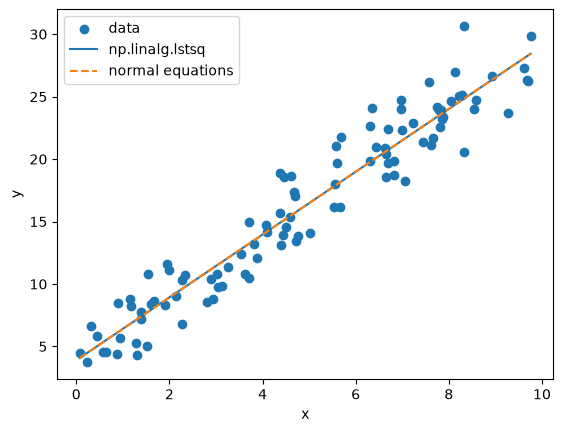

In [17]:
X_design = np.column_stack([np.ones(len(x)), x])

coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    X_design, y, rcond=None
)

intercept, slope = coefficients
y_pred = X_design @ coefficients

mse_value = np.mean((y - y_pred) ** 2)

print(f"Estimated intercept: {intercept:.3f}")
print(f"Estimated slope:     {slope:.3f}")
print(f"MSE:                 {mse_value:.3f}")

coefficients_normal = (
    np.linalg.inv(X_design.T @ X_design)
    @ X_design.T
    @ y
)

intercept_normal, slope_normal = coefficients_normal
print("Normal-equation coefficients:")
print(coefficients_normal)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line
y_line_normal = intercept_normal + slope_normal * x_line

plt.scatter(x, y, label="data")

plt.plot(
    x_line,
    y_line,
    label="np.linalg.lstsq"
)

plt.plot(
    x_line,
    y_line_normal,
    "--",
    label="normal equations"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Numerical linear-algebra routines such as `lstsq` are usually more stable and avoid explicitly forming an inverse.  
Explicit inversion is also unnecessary when the real goal is to solve a linear system.